In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import random
import time
import requests

sns.set_style('darkgrid')

# Define Common stock symbols/ names and index names

In [11]:
tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "NVDA", "TSLA", "ADBE", "CRM", "ORCL",
    "JPM", "BAC", "GS", "MS", "WFC",
    "C", "BLK", "AXP", "SCHW", "USB",
    "JNJ", "PFE", "MRK", "LLY", "ABBV",
    "TMO", "UNH", "CVS", "AMGN", "GILD",
    "KO", "PEP", "WMT", "COST", "HD",
    "MCD", "NKE", "SBUX", "TGT", "DIS",
    "XOM", "CVX", "COP", "SLB", "EOG",
    "BA", "CAT", "GE", "HON", "UPS",
    "SPY", "QQQ", "IWM", "DIA", "VTI"]

index_tickers = [
    "^GSPC", "^DJI", "^IXIC", "^NDX",
    "^RUT","^VIX", "^NYA", "^FTSE", "^GDAXI",
    "^FCHI", "^N225", "^HSI", "^STOXX50E", "^BSESN",
    "^AXJO", "^MXX", "^BVSP", "^KS11", "^TWII", "^GSPTSE" ]

# Import stock data from y finance using stock ticker names

In [13]:
all_stocks = {}

print(f"Starting download of {len(tickers)} tickers...")

for i, ticker in enumerate(tickers):
    try:
        # Download data
        data = yf.download(ticker, start='2025-01-01', end='2025-12-31', progress=False)
        
        if not data.empty:
            all_stocks[ticker] = data
            print(f"[{i+1}/{len(tickers)}] Successfully downloaded {ticker}")
        else:
            print(f"[{i+1}/{len(tickers)}] No data found for {ticker}")

        # The 'Human Jitter' Strategy:
        # Wait between 3 and 7 seconds so Yahoo doesn't see a perfect pattern
        wait = random.uniform(1, 3)
        time.sleep(wait)

    except Exception as e:
        print(f"Error on {ticker}: {e}")
        # If we hit a 429, take a long break
        if "429" in str(e):
            print("Rate limit hit! Sleeping for 5 minutes...")
            time.sleep(300)

# Combine into a single MultiIndex DataFrame
final_df = pd.concat(all_stocks, axis=1, keys=all_stocks.keys())
print("Download Complete!")

Starting download of 55 tickers...
[1/55] Successfully downloaded AAPL
[2/55] Successfully downloaded MSFT
[3/55] Successfully downloaded GOOGL
[4/55] Successfully downloaded AMZN
[5/55] Successfully downloaded META
[6/55] Successfully downloaded NVDA
[7/55] Successfully downloaded TSLA
[8/55] Successfully downloaded ADBE
[9/55] Successfully downloaded CRM
[10/55] Successfully downloaded ORCL
[11/55] Successfully downloaded JPM
[12/55] Successfully downloaded BAC
[13/55] Successfully downloaded GS
[14/55] Successfully downloaded MS
[15/55] Successfully downloaded WFC
[16/55] Successfully downloaded C
[17/55] Successfully downloaded BLK
[18/55] Successfully downloaded AXP
[19/55] Successfully downloaded SCHW
[20/55] Successfully downloaded USB
[21/55] Successfully downloaded JNJ
[22/55] Successfully downloaded PFE
[23/55] Successfully downloaded MRK
[24/55] Successfully downloaded LLY
[25/55] Successfully downloaded ABBV
[26/55] Successfully downloaded TMO
[27/55] Successfully downloade

In [29]:
final_df.head()

AAPL                                                \
Price            Close        High         Low        Open    Volume   
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2025-01-02  242.525177  247.746654  240.506207  247.577564  55740700   
2025-01-03  242.037827  242.853364  240.575812  242.037827  40244100   
2025-01-06  243.668915  245.986258  241.878691  242.982661  45045600   
2025-01-07  240.894089  244.215939  240.038760  241.659894  40856000   
2025-01-08  241.381409  242.385931  238.745812  240.605648  37628900   

                  MSFT                                                ...  \
Price            Close        High         Low        Open    Volume  ...   
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT  ...   
Date                                                                  ...   
2025-01-02  414.568604  421.986845  410.874369  421.452012  16896500  ...   
2025-01-03  419.292877  419.966353  415.519392  417.044612  16662900  ...   
2025-01-06  423.749756  430.157753  421.402473  423.898312  20573600  ...   
2025-01-07  418.322266  426.522914  416.767304  424.888733  18139100  ...   
2025-01-08  420.491333  422.878241  417.500285  419.401869  15054600  ...   

                   DIA                                               \
Price            Close        High         Low        Open   Volume   
Ticker             DIA         DIA         DIA         DIA      DIA   
Date                                                                  
2025-01-02  416.615936  421.688470  414.443408  421.078985  4231500   
2025-01-03  419.919006  420.518652  417.009191  418.631215  2203200   
2025-01-06  419.889435  423.811788  418.857216  421.590089  3463300   
2025-01-07  418.119934  422.042317  416.674852  421.629424  2053900   
2025-01-08  418.906494  419.329198  416.085150  418.198698  2020200   

                   VTI                                               
Price            Close        High         Low        Open   Volume  
Ticker             VTI         VTI         VTI         VTI      VTI  
Date                                                                 
2025-01-02  285.771729  289.022032  283.884758  287.935321  3796400  
2025-01-03  289.525909  289.812421  286.690524  287.154858  2726800  
2025-01-06  291.146149  293.319600  290.385415  291.640119  3678600  
2025-01-07  287.895782  292.301989  286.897953  292.272352  3317000  
2025-01-08  288.162537  288.725670  286.018722  287.905693  2971300  

[5 rows x 275 columns]

In [30]:
stock_data = final_df.copy()
stock_data.columns = stock_data.columns.swaplevel(0, 1)
stock_data.sort_index(axis=1, level=0, inplace=True)

## Plot the Amazon stock close price for the given timeframe

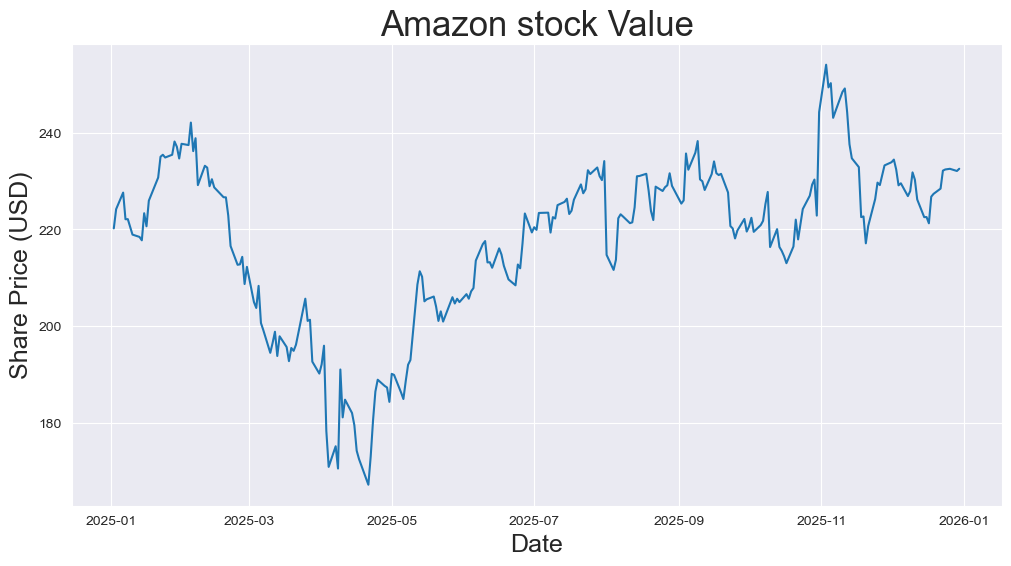

In [34]:
plt.figure(figsize = (12, 6))
plt.plot(stock_data['Close']['AMZN'])

plt.xlabel('Date', size = 18)

plt.ylabel('Share Price (USD)', size = 18)
plt.title('Amazon stock Value', size = 25)
plt.show()

## The value of a stock is not a good measurement
- There's a whole spread of prices across all these tickers

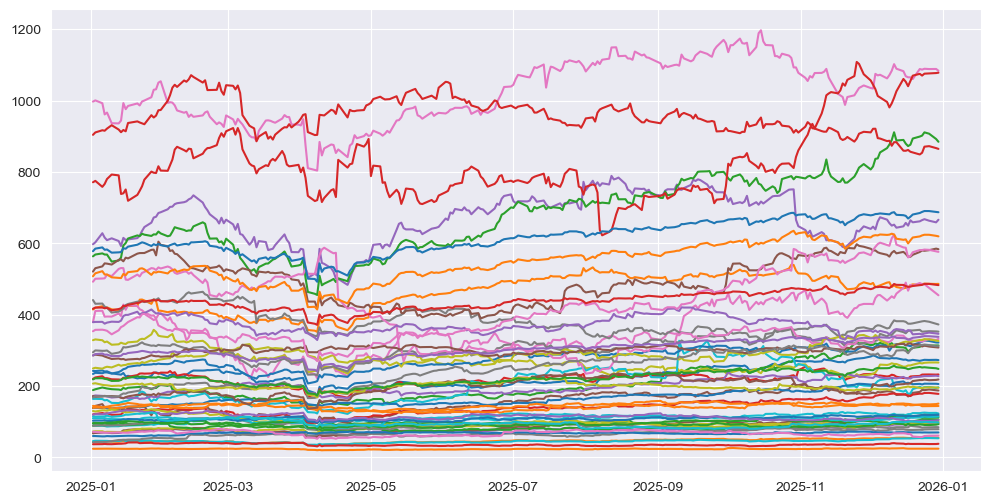

Values of a share of stock is not a good measurement.


In [35]:

plt.figure(figsize = (12, 6))

for ticker in tickers:
    plt.plot(stock_data['Close'][ticker])


plt.show()


print('Values of a share of stock is not a good measurement.')

## The return (%) is a better measure

In [ ]:

#Log-returns and returns of stock

stock_returns = 1+ stock_data['Close'].pct_change() # S_{t1 + i dt}/S_{t1 + i dt}

stock_returns.iloc[0] = 1

stock_log_returns = np.log(stock_returns)

stock_total_log_returns = np.cumsum(np.log(stock_returns))

total_stock_returns = np.exp(stock_total_log_returns) # S_{t2}/S_{t1} as a product of stock returns, but done in a numerically stable way

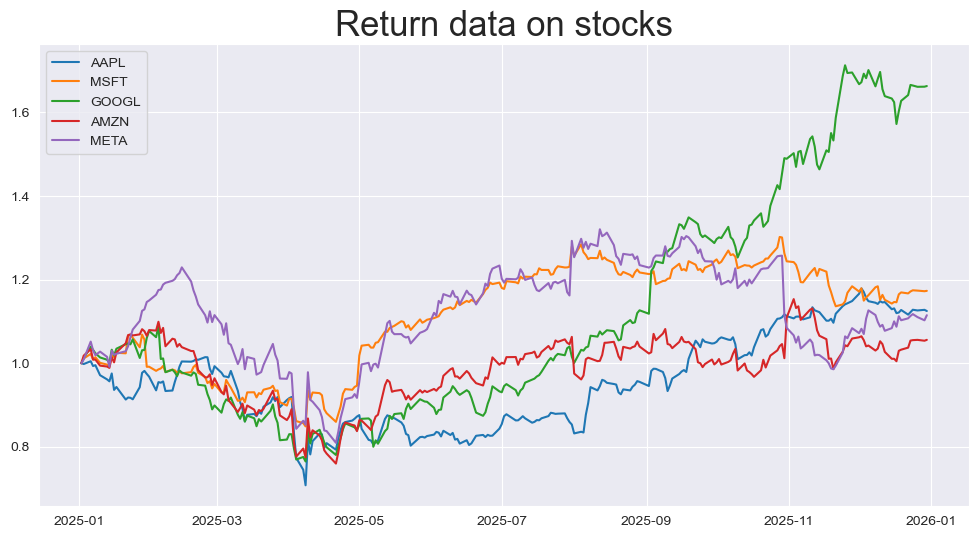

The return of stock is more relevant to understanding investments in that index.


In [37]:
plt.figure(figsize = (12, 6))

for ticker in tickers[0:5]:
    plt.plot(total_stock_returns[ticker], label = ticker)
    
plt.legend()
plt.title('Return data on stocks', size = 25)
plt.show()


print('The return of stock is more relevant to understanding investments in that index.')

## Let's define the volatility of the stock
- Volatility of a stock/portfolio is defined as the yearly staandard deviation of the log-returns of the stock 

In [38]:
ticker_vols = stock_log_returns.std()*np.sqrt(252) # Normalize the standard deviation for a year

for ticker in tickers:
    print(f'Volatility of {ticker}: {ticker_vols[ticker]}')

Volatility of AAPL: Ticker
AAPL    0.321595
dtype: float64
Volatility of MSFT: Ticker
MSFT    0.240551
dtype: float64
Volatility of GOOGL: Ticker
GOOGL    0.322722
dtype: float64
Volatility of AMZN: Ticker
AMZN    0.343231
dtype: float64
Volatility of META: Ticker
META    0.377828
dtype: float64
Volatility of NVDA: Ticker
NVDA    0.498384
dtype: float64
Volatility of TSLA: Ticker
TSLA    0.630146
dtype: float64
Volatility of ADBE: Ticker
ADBE    0.311773
dtype: float64
Volatility of CRM: Ticker
CRM    0.319554
dtype: float64
Volatility of ORCL: Ticker
ORCL    0.590733
dtype: float64
Volatility of JPM: Ticker
JPM    0.250092
dtype: float64
Volatility of BAC: Ticker
BAC    0.271087
dtype: float64
Volatility of GS: Ticker
GS    0.312216
dtype: float64
Volatility of MS: Ticker
MS    0.307078
dtype: float64
Volatility of WFC: Ticker
WFC    0.292626
dtype: float64
Volatility of C: Ticker
C    0.317533
dtype: float64
Volatility of BLK: Ticker
BLK    0.276947
dtype: float64
Volatility of AXP: 

## Let us create a random stock portfolio with different weights of how we spent our money on stocks

- Weights sum to one

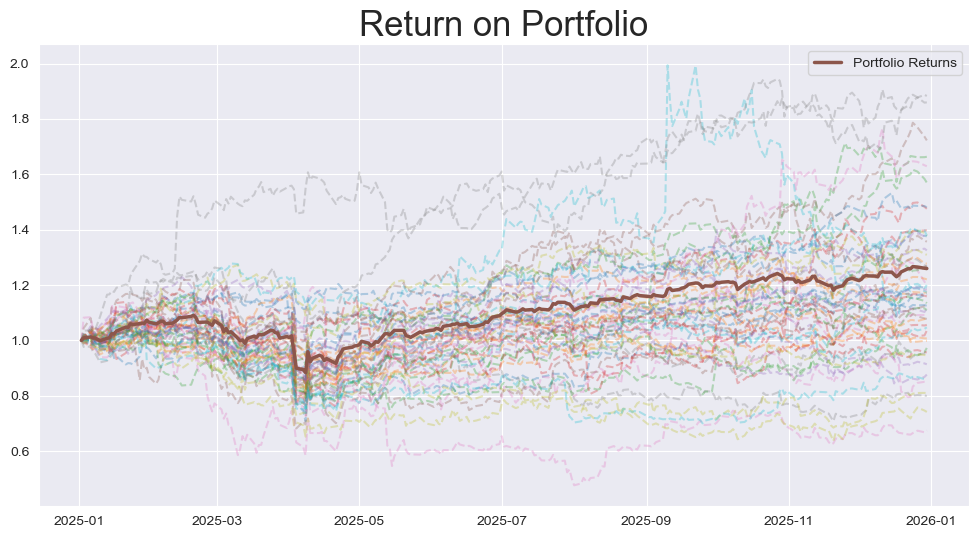

In [48]:
#Following line creates random positive numbers that add to 1 that we can use to simulate a random portfolio
w = np.random.dirichlet(np.ones(len(tickers))) # Weights that sum to one
#Create the total returns of a portfolio with weights w
portfolio_total_returns = 1+np.sum((total_stock_returns-1)*w,axis = 1) # weight each stock ticker and then multiply with percentage increase -1 as we derived in lecture to get percentage increase

#Visual of portfolio returns with individual stock returns
plt.figure(figsize = (12, 6))

for ticker in tickers:
    plt.plot(total_stock_returns[ticker], ls = '--', alpha = .3)

plt.plot(portfolio_total_returns, lw = 2.5, label = 'Portfolio Returns')

plt.legend()
plt.title('Return on Portfolio', size = 25)
plt.show()

## With this portfolio, find the volatility and compare to the average stock volatility

In [49]:
##Find volatility of portfolio

portfolio_pct_change = portfolio_total_returns.pct_change()

portfolio_pct_change.iloc[0] = 0

portfolio_vol = np.log(1 + portfolio_pct_change).std()*np.sqrt(252)


print(f'Volatility of random portfolio: {portfolio_vol}')

print('---'*30)

print(f'Average volatility of individual stocks: {np.mean(ticker_vols)}')

Volatility of random portfolio: 0.17804728923195792
------------------------------------------------------------------------------------------
Average volatility of individual stocks: 0.30340921198170484


### Reduced volatility by having a portfolio!